In [1]:
import pandas as pd
import numpy as np

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv'

In [3]:
!wget $data ## wget for downloading data

--2026-02-12 18:05:28--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.2’

data.csv.2          100%[===================>]   1.41M  --.-KB/s    in 0.03s   

2026-02-12 18:05:28 (43.9 MB/s) - ‘data.csv.2’ saved [1475504/1475504]



In [4]:
df = pd.read_csv('data.csv')

In [5]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [6]:
## doing some cleaning on the features names because there are a lot of differences between
## them, like: one have spaces, other have underscore, uppercase, lowercase -> make all consistent

df.columns = df.columns.str.replace(' ', '_').str.lower()

In [7]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [8]:
## there is the same problem with the values, they are inconsistent from one another
## first, find out which columns are strings because these manipulation won't work on columns that has numerical values

df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [9]:
## now we need to select these columns

strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [10]:
for column in strings:
    df[column] = df[column].str.lower().str.replace(' ', '_')

In [11]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [12]:
## looking what we have

df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [13]:
## Exploratory data analysis
## This means we want to understand how the data looks like, to know which values are there
## and learn more about the data and the problem

for column in df.columns:
    print(f"Column name: {column}")
    print(f"Head of the column: {df[column].unique()[:5]}")
    print(f"How many unique values are in {column}: {df[column].nunique()}")

Column name: make
Head of the column: <StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
How many unique values are in make: 48
Column name: model
Head of the column: <StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
How many unique values are in model: 914
Column name: year
Head of the column: [2011 2012 2013 1992 1993]
How many unique values are in year: 28
Column name: engine_fuel_type
Head of the column: <StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
How many unique values are in engine_fuel_type: 10
Column name: engine_hp
Head of the column: [335. 300. 230. 320. 172.]
How many unique values are in engine_hp: 356
Column name: engine_cylinders
Head of the column: [ 6.  4.  5.  8. 12.]
How many unique values are in engine_cylinders: 9
Column

In [14]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [15]:
## it is important to look at the prices graphically
## only looking at them as numbers are not that informative

import matplotlib.pyplot as plt
import seaborn as sns
## -> the plots can be displayed on a notebook
%matplotlib inline 

<Axes: xlabel='msrp', ylabel='Count'>

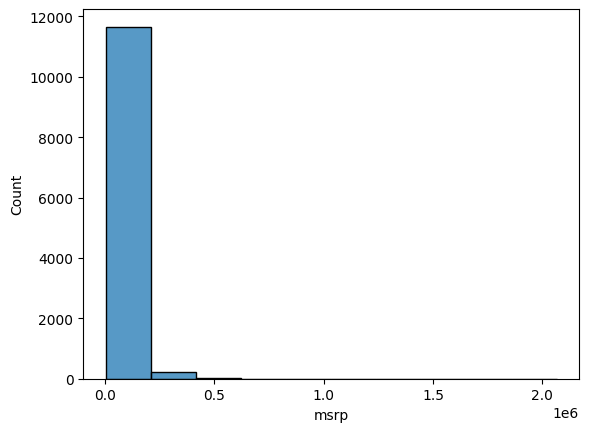

In [16]:
## look at the distribution of prices to see how many different prices are there
## bins is how many bars we have

sns.histplot(df.msrp, bins=10)

<Axes: xlabel='msrp', ylabel='Count'>

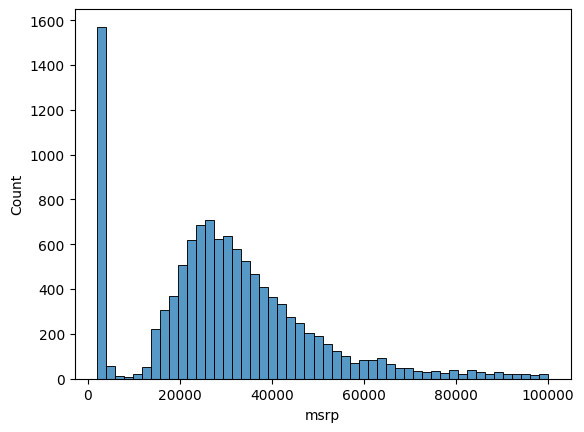

In [17]:
## zoom out and in a bit, let's look at prices at prices that are not so large

sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [18]:
## this is a very normal distribution since we have just a few people who can afford cars
## with big prices and a lot of people who can only buy cheaper cars
## but it is not good for ML, the tail can confuse the model

## we want to get rid of the tail by applying the logarithmic distribution to the price
## to get more compact values

price_logs = np.log1p(df.msrp)

In [19]:
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

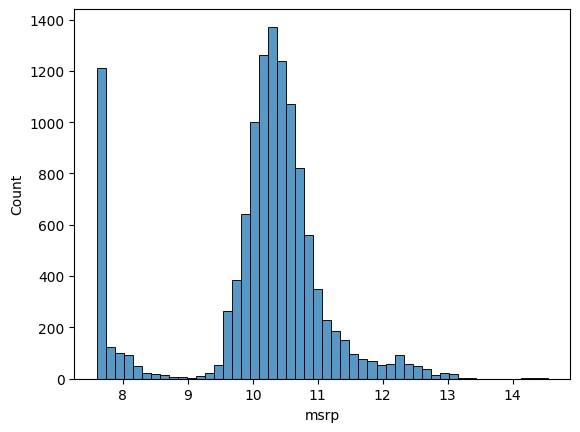

In [20]:
sns.histplot(price_logs, bins=50)

In [21]:
## you can see that the tail is gone, the large prices collapsed into the final area
## and all the cars for usual consumers are concentrated into the middle
## the shape now looks like a normal distribution (we have a clear center of the distribution)
## when it goes to left or right it goes down, which is the ideal situation for models (if your target variable looks like that)

In [22]:
## we still need to look for missing values
## nan -> not a number (in pandas it means it is missing)
## keep those in mind when training the model
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [23]:
## now we need to split our dataset into three different parts:
## train, validation and test
## we train the model using the train set, validate it using the validation set and
## use the test set on the end to see if the model is actually good and not just predicting right by chance

## a suggested % of the division of the sets is 60, 20, 20, respectively.
## but we need to know how much 20% represents out of the total number of samples in the dataset

dataset_size = len(df) ## total size of the dataset

validation_set_size = int(len(df) * 0.2) ## 20%
test_set_size = int(len(df) * 0.2)
train_set_size = dataset_size - validation_set_size - test_set_size

In [24]:
validation_set_size, test_set_size, train_set_size

(2382, 2382, 7150)

In [25]:
## now the we know the size of the dataframes, 
## we need to take these quantities out of the dataframe

## example
## 0-2382
## 2383-(2382+2382)
## (2382+2382) until the end

In [26]:
## we have a problem that everything is sequential
## so we don't have bmws in the training set for example
## we need to shuffle the data to make sure everything is mixed due to the orders we want to break

## we want to generate a sequence of numbers from 1 to n-1
idx = np.arange(dataset_size)

np.random.seed(2)
np.random.shuffle(idx)

df_train = df.iloc[idx[:train_set_size]] # everything from the end of the size of test and validation
df_validation = df.iloc[idx[train_set_size:train_set_size + validation_set_size]] ## everything until the end of this size
df_test = df.iloc[idx[train_set_size + validation_set_size:]] # everything from the end of the validation until the end of the size of test

In [27]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [28]:
len(df_train), len(df_validation), len(df_test)

(7150, 2382, 2382)

In [29]:
df_train = df_train.reset_index(drop=True)
df_validation = df_validation.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [30]:
y_train = np.log1p(df_train.msrp.values)
y_validation = np.log1p(df_validation.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [31]:
del df_validation['msrp']
del df_test['msrp']

In [32]:
len(y_train)

7150